In [ ]:
import numpy as np
import pandas as pd
import re
import spacy
import string
import matplotlib.pyplot as plt
import seaborn as sns

import logging
logging.basicConfig(level=logging.INFO)

pd.options.mode.chained_assignment = None

In [ ]:
!pip install --upgrade malaya
!pip install malaya-speech

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.8/293.8 kB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 37.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.9/235.9 kB 23.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 26.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.8 MB/s eta 0:00:00
  Created wheel for memoization: filename=memoization-0.4.0-py3-none-any.whl size=

# New Section

In [ ]:
%%time
import malaya


CPU times: user 2.55 s, sys: 179 ms, total: 2.73 s
Wall time: 3.24 s


/usr/local/lib/python3.10/dist-packages/malaya/tokenizer.py:214: FutureWarning: Possible nested set at position 3386
  self.tok = re.compile(r'({})'.format('|'.join(pipeline)))
/usr/local/lib/python3.10/dist-packages/malaya/tokenizer.py:214: FutureWarning: Possible nested set at position 3904
  self.tok = re.compile(r'({})'.format('|'.join(pipeline)))


In [ ]:
file = pd.read_csv("dataset_instagram-hashtag-scraper_2023-07-12_16-09-06-278 - dataset_instagram-hashtag-scraper_2023-07-12_16-09-06-278.csv")
df = file[["caption"]]
df["caption"] = df["caption"].astype(str)
file.head()

<ipython-input-2-8c02fe92ed1c>:1: DtypeWarning: Columns (8,41,42,78,80,81,82,83,85,86,87,88,90,91,92,93,95,96,97,98,100,101,102,103,105,106,107,108,110,111,112,113,115,116,117,118,120,121,122,123,125,126,127,128,130,131,132,133,135,136,137,138,140,141,142,143,145,146,147,148,150,151,152,157,159,175,177,178,179,180,182,183,184,185,187,188,189,190,192,193,194,195,197,198,199,200,202,203,204,205,207,208,209,210,212,213,214,215,217,218,219,220,222,223,224,225,227,228,229,230,232,233,234,235,237,238,239,240,242,243,244,245,247,248,249,250,252,253,254,257,258,259,260,262,263,264,269,271,282,284,285,286,287,289,290,291,292,294,295,296,297,299,300,301,302,304,305,306,307,309,310,311,312,314,315,316,317,319,320,321,322,324,325,326,333,344,346,347,348,349,351,352,353,354,356,357,358,359,361,362,363,364,366,367,368,369,371,372,373,378,391,393,394,395,396,398,399,400,401,403,404,405,406,408,409,410,411,413,414,415,416,418,419,420,421,423,424,425,426,428,429,430,431,433,434,435,436,438,439,440,441,

,id,ownerId,ownerUsername,ownerFullName,caption,locationId,locationName,shortCode,alt,type,...,status,commentsCount,likesCount,videoPlayCount,videoViewCount,timestamp,displayUrl,dimensionsHeight,dimensionsWidth,data/shortcode_media
0,3.145166e+18,5.816449e+09,muh_adi24,Muhammad Adi R,bodoh.\n-\n#bodoh #praumountain,2.524809e+14,Gunung Prau,Cul33eqLyZE,NaN,Image,...,NaN,0.0,5.0,NaN,NaN,2023-07-12T09:09:40.000Z,https://instagram.fist6-3.fna.fbcdn.net/v/t51....,1080.0,1080.0,NaN
1,3.144947e+18,5.070297e+10,sahabatjual2,NaN,Reposted from @thesunnah_path Orang bodoh itu ...,NaN,NaN,CulGMuthbnf,NaN,Image,...,NaN,0.0,0.0,NaN,NaN,2023-07-12T01:55:40.000Z,https://instagram.fssa10-1.fna.fbcdn.net/v/t51...,1080.0,1080.0,NaN
2,3.145200e+18,5.550122e+10,xklusif.my,Xklusif.my,Nak tuduh perlulah berasas \n\nBerita penuh di...,NaN,NaN,Cul_nIWJRHv,NaN,Image,...,NaN,0.0,4.0,NaN,NaN,2023-07-12T10:17:21.000Z,https://instagram.fpbc1-1.fna.fbcdn.net/v/t39....,1080.0,1080.0,NaN
3,3.144947e+18,4.927470e+10,muraniaga,Muraniaga.com,Reposted from @thesunnah_path Orang bodoh itu ...,NaN,NaN,CulGMv7BFEi,NaN,Image,...,NaN,0.0,0.0,NaN,NaN,2023-07-12T01:55:40.000Z,https://scontent-iad3-2.cdninstagram.com/v/t51...,1080.0,1080.0,NaN
4,3.144947e+18,4.560199e+10,cerdaslaundryindonesia9,cerdaslaundryindonesia,Reposted from @thesunnah_path Orang bodoh itu ...,NaN,NaN,CulGMwnB5qb,NaN,Image,...,NaN,0.0,0.0,NaN,NaN,2023-07-12T01:55:40.000Z,https://instagram.fbki2-1.fna.fbcdn.net/v/t51....,1080.0,1080.0,NaN


In [ ]:
# check missing value
file.isnull().sum()

id                          1
ownerId                     1
ownerUsername               1
ownerFullName             318
caption                    16
                        ...  
timestamp                   1
displayUrl                  1
dimensionsHeight            1
dimensionsWidth             1
data/shortcode_media    10301
Length: 732, dtype: int64

<ipython-input-23-a3eefac8971f>:1: DtypeWarning: Columns (8,41,42,78,80,81,82,83,85,86,87,88,90,91,92,93,95,96,97,98,100,101,102,103,105,106,107,108,110,111,112,113,115,116,117,118,120,121,122,123,125,126,127,128,130,131,132,133,135,136,137,138,140,141,142,143,145,146,147,148,150,151,152,157,159,175,177,178,179,180,182,183,184,185,187,188,189,190,192,193,194,195,197,198,199,200,202,203,204,205,207,208,209,210,212,213,214,215,217,218,219,220,222,223,224,225,227,228,229,230,232,233,234,235,237,238,239,240,242,243,244,245,247,248,249,250,252,253,254,257,258,259,260,262,263,264,269,271,282,284,285,286,287,289,290,291,292,294,295,296,297,299,300,301,302,304,305,306,307,309,310,311,312,314,315,316,317,319,320,321,322,324,325,326,333,344,346,347,348,349,351,352,353,354,356,357,358,359,361,362,363,364,366,367,368,369,371,372,373,378,391,393,394,395,396,398,399,400,401,403,404,405,406,408,409,410,411,413,414,415,416,418,419,420,421,423,424,425,426,428,429,430,431,433,434,435,436,438,439,440,441

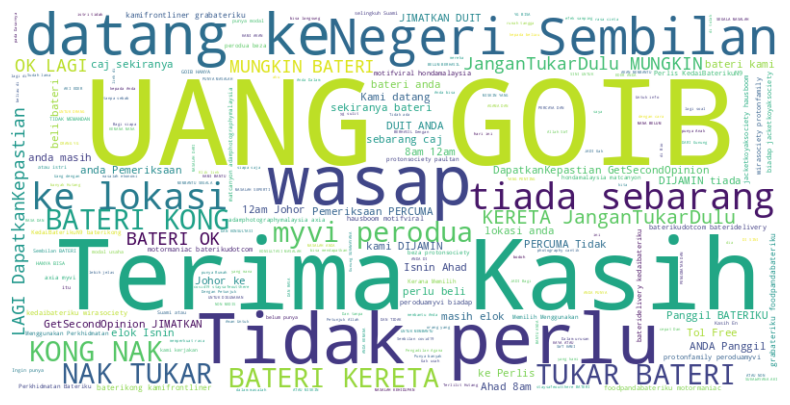

In [ ]:
from wordcloud import WordCloud
data = pd.read_csv("dataset_instagram-hashtag-scraper_2023-07-12_16-09-06-278 - dataset_instagram-hashtag-scraper_2023-07-12_16-09-06-278.csv")
text_data = data["caption"].dropna().str.cat(sep=' ')

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
plt.figure(figsize=(10, 5))  # Adjust the figure size (optional)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()
wordcloud.to_file("wordcloud_instagrm_raw.png")

In [ ]:
df["caption_lower"] = df["caption"].str.lower()
df.head()

,caption,caption_lower
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...


In [ ]:
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

df["caption_wo_punct"] = df["caption_lower"].apply(lambda text: remove_punctuation(text))
df.head()

,caption,caption_lower,caption_wo_punct
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain,bodoh\n\nbodoh praumountain
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...


In [ ]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Define your list of stopwords
stopwords_list = ['ada', 'inikah', 'sampai', 'adakah', 'inilah', 'sana', 'adakan', 'itu', 'sangat', 'adalah',
    'itukah', 'sangatlah', 'adanya', 'itulah', 'saya', 'adapun', 'jadi', 'se', 'agak', 'jangan',
    'seandainya', 'agar', 'janganlah', 'sebab', 'akan', 'jika', 'sebagai', 'aku', 'jikalau',
    'sebagaimana', 'akulah', 'jua', 'sebanyak', 'akupun', 'juapun', 'sebelum', 'al', 'juga',
    'sebelummu', 'alangkah', 'kalau', 'sebelumnya', 'allah', 'kami', 'sebenarnya', 'amat',
    'kamikah', 'secara', 'antara', 'kamipun', 'sedang', 'antaramu', 'kamu', 'sedangkan',
    'antaranya', 'kamukah', 'sedikit', 'apa', 'kamupun', 'sedikitpun', 'apa-apa', 'katakan',
    'segala', 'apabila', 'ke', 'sehingga', 'apakah', 'kecuali', 'sejak', 'apapun', 'kelak',
    'sekalian', 'atas', 'kembali', 'sekalipun', 'atasmu', 'kemudian', 'sekarang', 'atasnya',
    'kepada', 'sekitar', 'atau', 'kepadaku', 'selain', 'ataukah', 'kepadakulah', 'selalu',
    'ataupun', 'kepadamu', 'selama', 'bagaimana', 'kepadanya', 'selama-lamanya', 'bagaimanakah',
    'kepadanyalah', 'seluruh', 'bagi', 'kerana', 'seluruhnya', 'bagimu', 'kerananya', 'sementara',
    'baginya', 'kesan', 'semua', 'bahawa', 'ketika', 'semuanya', 'bahawasanya', 'kini',
    'semula', 'bahkan', 'kita', 'senantiasa', 'bahwa', 'ku', 'sendiri', 'banyak', 'kurang',
    'sentiasa', 'banyaknya', 'lagi', 'seolah', 'barangsiapa', 'lain', 'seolah-olah', 'bawah',
    'lalu', 'seorangpun', 'beberapa', 'lamanya', 'separuh', 'begitu', 'langsung', 'sepatutnya',
    'begitupun', 'lebih', 'seperti', 'belaka', 'maha', 'seraya', 'belum', 'mahu', 'sering',
    'belumkah', 'mahukah', 'serta', 'berada', 'mahupun', 'seseorang', 'berapa', 'maka',
    'sesiapa', 'berikan', 'malah', 'sesuatu', 'beriman', 'mana', 'sesudah', 'berkenaan',
    'manakah', 'sesudahnya', 'berupa', 'manapun', 'sesungguhnya', 'beserta', 'masih',
    'sesungguhnyakah', 'biarpun', 'masing', 'setelah', 'bila', 'masing-masing', 'setiap',
    'bilakah', 'melainkan', 'siapa', 'bilamana', 'memang', 'siapakah', 'bisa', 'mempunyai',
    'sini', 'boleh', 'mendapat', 'situ', 'bukan', 'mendapati', 'situlah', 'bukankah',
    'mendapatkan', 'suatu', 'bukanlah', 'mengadakan', 'sudah', 'dahulu', 'mengapa', 'sudahkah',
    'dalam', 'mengapakah', 'sungguh', 'dalamnya', 'mengenai', 'sungguhpun', 'dan', 'menjadi',
    'supaya', 'dapat', 'menyebabkan', 'tadinya', 'dapati', 'menyebabkannya', 'tahukah',
    'dapatkah', 'mereka', 'tak', 'dapatlah', 'merekalah', 'tanpa', 'dari', 'merekapun',
    'tanya', 'daripada', 'meskipun', 'tanyakanlah', 'daripadaku', 'mu', 'tapi', 'daripadamu',
    'nescaya', 'telah', 'daripadanya', 'niscaya', 'tentang', 'demi', 'nya', 'tentu', 'demikian',
    'olah', 'terdapat', 'demikianlah', 'oleh', 'terhadap', 'dengan', 'orang', 'terhadapmu',
    'dengannya', 'pada', 'termasuk', 'di', 'padahal', 'terpaksa', 'dia', 'padamu', 'tertentu',
    'dialah', 'padanya', 'tetapi', 'didapat', 'paling', 'tiada', 'didapati', 'para',
    'tiadakah', 'dimanakah', 'pasti', 'tiadalah', 'engkau', 'patut', 'tiap', 'engkaukah',
    'patutkah', 'tiap-tiap', 'engkaulah', 'per', 'tidak', 'engkaupun', 'pergilah', 'tidakkah',
    'hai', 'perkara', 'tidaklah', 'hampir', 'perkaranya', 'turut', 'hampir-hampir', 'perlu',
    'untuk', 'hanya', 'pernah', 'untukmu', 'hanyalah', 'pertama', 'wahai', 'hendak', 'pula',
    'walau', 'hendaklah', 'pun', 'walaupun', 'hingga', 'sahaja', 'ya', 'ia', 'saja', 'yaini',
    'iaitu', 'saling', 'yaitu', 'ianya', 'sama', 'yakni', 'ianya', 'sama-sama', 'yang',
    'inginkah', 'samakah', 'ini', 'sambil',]

# Function to remove stopwords from a given text
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords_list]
    return ' '.join(filtered_words)

# Apply the remove_stopwords function to the 'text' column and create a new 'text_wo_stop' column
df['caption_wo_stop'] = df["caption_wo_punct"].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,caption,caption_lower,caption_wo_punct,caption_wo_stop
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain,bodoh\n\nbodoh praumountain,bodoh bodoh praumountain
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...,reposted from thesunnahpath bodoh membaca menu...
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas berita penuh ig sto...
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...,reposted from thesunnahpath bodoh membaca menu...
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...,reposted from thesunnahpath bodoh membaca menu...


In [ ]:
from collections import Counter
cnt = Counter()
for text in df["caption_wo_stop"].values:
    for word in text.split():
        cnt[word] += 1

cnt.most_common(10)

[('anda', 8209),
 ('bateri', 6702),
 ('rasuah', 4327),
 ('cerai', 3023),
 ('masalah', 2700),
 ('baterikucom', 2676),
 ('yg', 2620),
 ('bodoh', 2427),
 ('uang', 2383),
 ('goib', 2274)]

In [ ]:
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
def remove_freqwords(text):
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

df["caption_wo_stopfreq"] = df["caption_wo_stop"].apply(lambda text: remove_freqwords(text))
df.head()

,caption,caption_lower,caption_wo_punct,caption_wo_stop,caption_wo_stopfreq
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain,bodoh\n\nbodoh praumountain,bodoh bodoh praumountain,praumountain
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...,reposted from thesunnahpath bodoh membaca menu...,reposted from thesunnahpath membaca menulistap...
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...,reposted from thesunnahpath bodoh membaca menu...,reposted from thesunnahpath membaca menulistap...
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath orang bodoh itu bu...,reposted from thesunnahpath bodoh membaca menu...,reposted from thesunnahpath membaca menulistap...


In [ ]:
# Drop unnecessary columns
df.drop(["caption_wo_punct", "caption_wo_stop"], axis=1, inplace=True)
n_rare_words = 10
RAREWORDS = set([w for (w, wc) in cnt.most_common()[:-n_rare_words-1:-1]])

def remove_rarewords(text):
    return " ".join([word for word in str(text).split() if word not in RAREWORDS])

df["caption_wo_stopfreqrare"] = df["caption_wo_stopfreq"].apply(lambda text: remove_rarewords(text))
df.head()

,caption,caption_lower,caption_wo_stopfreq,caption_wo_stopfreqrare
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain,praumountain,praumountain
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...


In [ ]:
# Drop unnecessary columns
df.drop(["caption_wo_stopfreq"], axis=1, inplace=True)

# Reference : https://gist.github.com/slowkow/7a7f61f495e3dbb7e3d767f97bd7304b
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df["caption_remove_emoji"] = df["caption_wo_stopfreqrare"].apply(lambda text: remove_emoji(text))
df.head()

,caption,caption_lower,caption_wo_stopfreqrare,caption_remove_emoji
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain,praumountain,praumountain
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...


In [ ]:
EMOTICONS = {
    u":‑\)":"Happy face or smiley",
    u":\)":"Happy face or smiley",
    u":-\]":"Happy face or smiley",
    u":\]":"Happy face or smiley",
    u":-3":"Happy face smiley",
    u":3":"Happy face smiley",
    u":->":"Happy face smiley",
    u":>":"Happy face smiley",
    u"8-\)":"Happy face smiley",
    u":o\)":"Happy face smiley",
    u":-\}":"Happy face smiley",
    u":\}":"Happy face smiley",
    u":-\)":"Happy face smiley",
    u":c\)":"Happy face smiley",
    u":\^\)":"Happy face smiley",
    u"=\]":"Happy face smiley",
    u"=\)":"Happy face smiley",
    u":‑D":"Laughing, big grin or laugh with glasses",
    u":D":"Laughing, big grin or laugh with glasses",
    u"8‑D":"Laughing, big grin or laugh with glasses",
    u"8D":"Laughing, big grin or laugh with glasses",
    u"X‑D":"Laughing, big grin or laugh with glasses",
    u"XD":"Laughing, big grin or laugh with glasses",
    u"=D":"Laughing, big grin or laugh with glasses",
    u"=3":"Laughing, big grin or laugh with glasses",
    u"B\^D":"Laughing, big grin or laugh with glasses",
    u":-\)\)":"Very happy",
    u":‑\(":"Frown, sad, andry or pouting",
    u":-\(":"Frown, sad, andry or pouting",
    u":\(":"Frown, sad, andry or pouting",
    u":‑c":"Frown, sad, andry or pouting",
    u":c":"Frown, sad, andry or pouting",
    u":‑<":"Frown, sad, andry or pouting",
    u":<":"Frown, sad, andry or pouting",
    u":‑\[":"Frown, sad, andry or pouting",
    u":\[":"Frown, sad, andry or pouting",
    u":-\|\|":"Frown, sad, andry or pouting",
    u">:\[":"Frown, sad, andry or pouting",
    u":\{":"Frown, sad, andry or pouting",
    u":@":"Frown, sad, andry or pouting",
    u">:\(":"Frown, sad, andry or pouting",
    u":'‑\(":"Crying",
    u":'\(":"Crying",
    u":'‑\)":"Tears of happiness",
    u":'\)":"Tears of happiness",
    u"D‑':":"Horror",
    u"D:<":"Disgust",
    u"D:":"Sadness",
    u"D8":"Great dismay",
    u"D;":"Great dismay",
    u"D=":"Great dismay",
    u"DX":"Great dismay",
    u":‑O":"Surprise",
    u":O":"Surprise",
    u":‑o":"Surprise",
    u":o":"Surprise",
    u":-0":"Shock",
    u"8‑0":"Yawn",
    u">:O":"Yawn",
    u":-\*":"Kiss",
    u":\*":"Kiss",
    u":X":"Kiss",
    u";‑\)":"Wink or smirk",
    u";\)":"Wink or smirk",
    u"\*-\)":"Wink or smirk",
    u"\*\)":"Wink or smirk",
    u";‑\]":"Wink or smirk",
    u";\]":"Wink or smirk",
    u";\^\)":"Wink or smirk",
    u":‑,":"Wink or smirk",
    u";D":"Wink or smirk",
    u":‑P":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":P":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"X‑P":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"XP":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":‑Þ":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":Þ":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":b":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"d:":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"=p":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u">:P":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":‑/":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":/":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":-[.]":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u">:[(\\\)]":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u">:/":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":[(\\\)]":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u"=/":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u"=[(\\\)]":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":L":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u"=L":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":S":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":‑\|":"Straight face",
    u":\|":"Straight face",
    u":$":"Embarrassed or blushing",
    u":‑x":"Sealed lips or wearing braces or tongue-tied",
    u":x":"Sealed lips or wearing braces or tongue-tied",
    u":‑#":"Sealed lips or wearing braces or tongue-tied",
    u":#":"Sealed lips or wearing braces or tongue-tied",
    u":‑&":"Sealed lips or wearing braces or tongue-tied",
    u":&":"Sealed lips or wearing braces or tongue-tied",
    u"O:‑\)":"Angel, saint or innocent",
    u"O:\)":"Angel, saint or innocent",
    u"0:‑3":"Angel, saint or innocent",
    u"0:3":"Angel, saint or innocent",
    u"0:‑\)":"Angel, saint or innocent",
    u"0:\)":"Angel, saint or innocent",
    u":‑b":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"0;\^\)":"Angel, saint or innocent",
    u">:‑\)":"Evil or devilish",
    u">:\)":"Evil or devilish",
    u"\}:‑\)":"Evil or devilish",
    u"\}:\)":"Evil or devilish",
    u"3:‑\)":"Evil or devilish",
    u"3:\)":"Evil or devilish",
    u">;\)":"Evil or devilish",
    u"\|;‑\)":"Cool",
    u"\|‑O":"Bored",
    u":‑J":"Tongue-in-cheek",
    u"#‑\)":"Party all night",
    u"%‑\)":"Drunk or confused",
    u"%\)":"Drunk or confused",
    u":-###..":"Being sick",
    u":###..":"Being sick",
    u"<:‑\|":"Dump",
    u"\(>_<\)":"Troubled",
    u"\(>_<\)>":"Troubled",
    u"\(';'\)":"Baby",
    u"\(\^\^>``":"Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    u"\(\^_\^;\)":"Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    u"\(-_-;\)":"Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    u"\(~_~;\) \(・\.・;\)":"Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    u"\(-_-\)zzz":"Sleeping",
    u"\(\^_-\)":"Wink",
    u"\(\(\+_\+\)\)":"Confused",
    u"\(\+o\+\)":"Confused",
    u"\(o\|o\)":"Ultraman",
    u"\^_\^":"Joyful",
    u"\(\^_\^\)/":"Joyful",
    u"\(\^O\^\)／":"Joyful",
    u"\(\^o\^\)／":"Joyful",
    u"\(__\)":"Kowtow as a sign of respect, or dogeza for apology",
    u"_\(\._\.\)_":"Kowtow as a sign of respect, or dogeza for apology",
    u"<\(_ _\)>":"Kowtow as a sign of respect, or dogeza for apology",
    u"<m\(__\)m>":"Kowtow as a sign of respect, or dogeza for apology",
    u"m\(__\)m":"Kowtow as a sign of respect, or dogeza for apology",
    u"m\(_ _\)m":"Kowtow as a sign of respect, or dogeza for apology",
    u"\('_'\)":"Sad or Crying",
    u"\(/_;\)":"Sad or Crying",
    u"\(T_T\) \(;_;\)":"Sad or Crying",
    u"\(;_;":"Sad of Crying",
    u"\(;_:\)":"Sad or Crying",
    u"\(;O;\)":"Sad or Crying",
    u"\(:_;\)":"Sad or Crying",
    u"\(ToT\)":"Sad or Crying",
    u";_;":"Sad or Crying",
    u";-;":"Sad or Crying",
    u";n;":"Sad or Crying",
    u";;":"Sad or Crying",
    u"Q\.Q":"Sad or Crying",
    u"T\.T":"Sad or Crying",
    u"QQ":"Sad or Crying",
    u"Q_Q":"Sad or Crying",
    u"\(-\.-\)":"Shame",
    u"\(-_-\)":"Shame",
    u"\(一一\)":"Shame",
    u"\(；一_一\)":"Shame",
    u"\(=_=\)":"Tired",
    u"\(=\^\·\^=\)":"cat",
    u"\(=\^\·\·\^=\)":"cat",
    u"=_\^=	":"cat",
    u"\(\.\.\)":"Looking down",
    u"\(\._\.\)":"Looking down",
    u"\^m\^":"Giggling with hand covering mouth",
    u"\(\・\・?":"Confusion",
    u"\(?_?\)":"Confusion",
    u">\^_\^<":"Normal Laugh",
    u"<\^!\^>":"Normal Laugh",
    u"\^/\^":"Normal Laugh",
    u"\（\*\^_\^\*）" :"Normal Laugh",
    u"\(\^<\^\) \(\^\.\^\)":"Normal Laugh",
    u"\(^\^\)":"Normal Laugh",
    u"\(\^\.\^\)":"Normal Laugh",
    u"\(\^_\^\.\)":"Normal Laugh",
    u"\(\^_\^\)":"Normal Laugh",
    u"\(\^\^\)":"Normal Laugh",
    u"\(\^J\^\)":"Normal Laugh",
    u"\(\*\^\.\^\*\)":"Normal Laugh",
    u"\(\^—\^\）":"Normal Laugh",
    u"\(#\^\.\^#\)":"Normal Laugh",
    u"\（\^—\^\）":"Waving",
    u"\(;_;\)/~~~":"Waving",
    u"\(\^\.\^\)/~~~":"Waving",
    u"\(-_-\)/~~~ \($\·\·\)/~~~":"Waving",
    u"\(T_T\)/~~~":"Waving",
    u"\(ToT\)/~~~":"Waving",
    u"\(\*\^0\^\*\)":"Excited",
    u"\(\*_\*\)":"Amazed",
    u"\(\*_\*;":"Amazed",
    u"\(\+_\+\) \(@_@\)":"Amazed",
    u"\(\*\^\^\)v":"Laughing,Cheerful",
    u"\(\^_\^\)v":"Laughing,Cheerful",
    u"\(\(d[-_-]b\)\)":"Headphones,Listening to music",
    u'\(-"-\)':"Worried",
    u"\(ーー;\)":"Worried",
    u"\(\^0_0\^\)":"Eyeglasses",
    u"\(\＾ｖ\＾\)":"Happy",
    u"\(\＾ｕ\＾\)":"Happy",
    u"\(\^\)o\(\^\)":"Happy",
    u"\(\^O\^\)":"Happy",
    u"\(\^o\^\)":"Happy",
    u"\)\^o\^\(":"Happy",
    u":O o_O":"Surprised",
    u"o_0":"Surprised",
    u"o\.O":"Surpised",
    u"\(o\.o\)":"Surprised",
    u"oO":"Surprised",
    u"\(\*￣m￣\)":"Dissatisfied",
    u"\(‘A`\)":"Snubbed or Deflated"
}

In [ ]:
def remove_emoticons(text):
    emoticon_pattern = re.compile(u'(' + u'|'.join(k for k in EMOTICONS) + u')')
    return emoticon_pattern.sub(r'', text)

df["caption_remove_emoticons"] = df["caption_remove_emoji"].apply(lambda text: remove_emoticons(text))
df.head()

,caption,caption_lower,caption_wo_stopfreqrare,caption_remove_emoji,caption_remove_emoticons
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain,praumountain,praumountain,praumountain
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...


In [ ]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

df["caption_remove_urls"] = df["caption_remove_emoticons"].apply(lambda text: remove_urls(text))
df.head()

,caption,caption_lower,caption_wo_stopfreqrare,caption_remove_emoji,caption_remove_emoticons,caption_remove_urls
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain,praumountain,praumountain,praumountain,praumountain
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...


In [ ]:
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

df["caption_remove_html"] = df["caption_remove_urls"].apply(lambda text: remove_html(text))
df.head()
df.to_csv('SMDA_Inatgram_preprocessed.csv', index=False)

In [ ]:
model = malaya.spelling_correction.spylls.load()

def correct(text):
    return model.correct_text(text)

# Apply the correct function to create a new column
df["text_spell_correct"] = df["text_remove_html"].apply(lambda text: correct(text))

# Display the DataFrame
df.head()

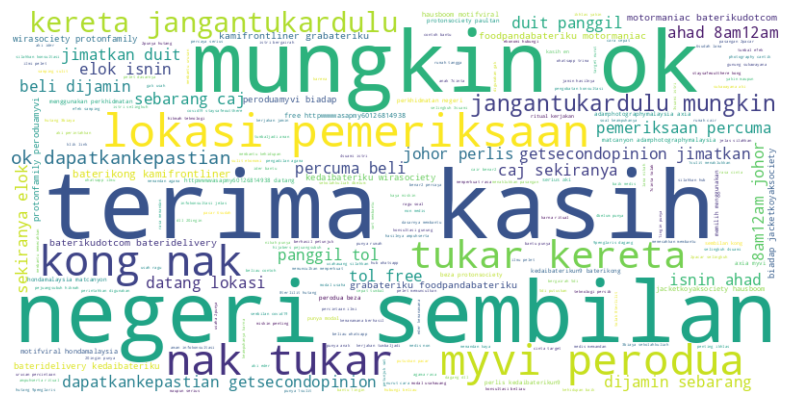

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
data = pd.read_csv("SMDA_Inatgram_preprocessed.csv")
text_column_name = "caption_remove_html"
text_data = data[text_column_name].dropna().str.cat(sep=' ')

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
plt.figure(figsize=(10, 5))  # Adjust the figure size (optional)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()
wordcloud.to_file("wordcloud_instagrm_clean.png")

In [ ]:
malaya.sentiment.label

['negative', 'neutral', 'positive']

In [ ]:
model = malaya.sentiment.transformer(model='xlnet')

In [ ]:
def textSentiment(text):
    result = model.predict([text])  # Wrap text in a list
    sentiment = " ".join(result)  # Join the predicted sentiment labels into a single string
    return sentiment

df["Sentiment"] = df["caption_remove_html"].apply(lambda text: textSentiment(text))
df.head()

,caption,caption_lower,caption_wo_stopfreqrare,caption_remove_emoji,caption_remove_emoticons,caption_remove_urls,caption_remove_html,Sentiment
0,bodoh.\n-\n#bodoh #praumountain,bodoh.\n-\n#bodoh #praumountain,praumountain,praumountain,praumountain,praumountain,praumountain,neutral
1,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,negative
2,Nak tuduh perlulah berasas \n\nBerita penuh di...,nak tuduh perlulah berasas \n\nberita penuh di...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...,nak tuduh perlulah berasas berita penuh ig sto...,negative
3,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,negative
4,Reposted from @thesunnah_path Orang bodoh itu ...,reposted from @thesunnah_path orang bodoh itu ...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,reposted from thesunnahpath membaca menulistap...,negative


In [ ]:
df["Sentiment"].value_counts()

KeyError: ignored

In [ ]:
df.to_csv('SMDA_Instagram.csv', index=False)